# Evaluating the Impact of Defensive Efficiency on NBA Team Success (2025-2026 Season)

### An Empirical Analysis of the “Defense is 50% of the Game” Claim (2025-26 Season)

This project attempts to investigate whether defensive performance is as significant as offensive performance in determining the success of an NBA team.

## Motivation

This project was mostly inspired by a statement that Victor Wembanyama made during an NBA post-game interview. He claimed that “defense is 50% of the game” and is significantly undervalued in modern basketball analysis, more specifically in discussions surrounding MVP voting.

In his statement, Wembanyama emphasized that defensive impact is widely overlooked when compared to pure scoring statistics, despite being an equally important factor to winning basketball games.

This inspired me to question and test his statement using quantitative data:

If defense truly represents half of basketball, does it show up proportionally in real team success?

This project uses NBA team-level data from the 2025-26 season to test this claim quantitatively by comparing the impact of offensive and defensive efficiency on winning outcomes.

## Research Question

To what extent does defensive performance contribute to NBA team success, and is it as influential as offensive performance in determining winning outcomes?

## Objective

The primary goal of the project is to analyze and compare the impact of offensive and defensive efficiency on NBA team winning percentage.

We aim to determine whether defensive performance is as strong a predictor of success as offensive performance.

## Data Collection

This analysis uses team-level advanced statistics using the NBA API advanced statistics endpoint for the 2025-26 regular season.

The dataset includes statistics such as offensive rating, defensive rating, net rating, and win percentage for all 30 NBA teams.

## 1. Data Preparation
The dataset was filtered to include only relevant performance statistics/ metrics in order to evaluate team success, and offensive and defensive measures.  

Variables related to offensive efficiency, defensive efficiency, and overall team success were specifically selected and organized into a structured dataframe for statistical analysis and visualization.

This section outlines the process of data extraction, inspection, and preparation before analysis.

In [152]:
%pip install pandas numpy matplotlib nba_api statsmodels ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


The NBA team performance data for the 2025-26 regular season was extracted using the NBA Stats API, in which the dataset includes advanced offensive, defensive, and overall efficiency metrics at the team level.

In [153]:
from nba_api.stats.endpoints import leaguedashteamstats
import pandas as pd

print("Imports successful")

Imports successful


In [154]:
stats = leaguedashteamstats.LeagueDashTeamStats(season='2025-26', season_type_all_star='Regular Season', measure_type_detailed_defense='Advanced')
df = stats.get_data_frames()[0]
df.head()

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,...,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,PACE_RANK,PIE_RANK
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.0,113.2,115.0,111.0,...,3,2,20,9,17,8,10,12,5,14
1,1610612738,Boston Celtics,82,56,26,0.683,3946.0,116.8,120.0,109.7,...,9,22,5,6,3,3,11,13,30,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.0,105.8,108.2,116.0,...,29,20,21,22,27,29,30,30,26,29
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.0,114.7,118.4,111.9,...,23,16,2,2,2,28,12,10,27,10
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.0,110.5,112.1,115.1,...,13,8,26,7,16,21,14,16,3,21


The structure and columns of the dataset was inspected to understand available variables and ensure successful data retrieval. This also helps show the data that can be worked with the following dataset.

In [155]:
df.columns.tolist()

['TEAM_ID',
 'TEAM_NAME',
 'GP',
 'W',
 'L',
 'W_PCT',
 'MIN',
 'E_OFF_RATING',
 'OFF_RATING',
 'E_DEF_RATING',
 'DEF_RATING',
 'E_NET_RATING',
 'NET_RATING',
 'AST_PCT',
 'AST_TO',
 'AST_RATIO',
 'OREB_PCT',
 'DREB_PCT',
 'REB_PCT',
 'TM_TOV_PCT',
 'EFG_PCT',
 'TS_PCT',
 'E_PACE',
 'PACE',
 'PACE_PER40',
 'POSS',
 'PIE',
 'GP_RANK',
 'W_RANK',
 'L_RANK',
 'W_PCT_RANK',
 'MIN_RANK',
 'OFF_RATING_RANK',
 'DEF_RATING_RANK',
 'NET_RATING_RANK',
 'AST_PCT_RANK',
 'AST_TO_RANK',
 'AST_RATIO_RANK',
 'OREB_PCT_RANK',
 'DREB_PCT_RANK',
 'REB_PCT_RANK',
 'TM_TOV_PCT_RANK',
 'EFG_PCT_RANK',
 'TS_PCT_RANK',
 'PACE_RANK',
 'PIE_RANK']

To focus the analysis on team performance efficiency, a specific subset of relevant variables were selected. These include offensive rating, defensive rating, net rating, and other advanced metrics that contribute to winning outcomes.

This selection allows us to isolate factors that may influence team success and directly relate them to win percentage. The new data frames also makes it more efficient to analyze relevant data altogether. 

In [156]:
selected_df = df[[
    'TEAM_NAME',
    'W_PCT',
    'OFF_RATING',
    'DEF_RATING',
    'NET_RATING',
    'EFG_PCT',
    'TS_PCT',
    'DREB_PCT',
    'TM_TOV_PCT',
    'PACE',
    'PIE'
]]

selected_df.head()

,TEAM_NAME,W_PCT,OFF_RATING,DEF_RATING,NET_RATING,EFG_PCT,TS_PCT,DREB_PCT,TM_TOV_PCT,PACE,PIE
0,Atlanta Hawks,0.561,115.0,112.9,2.2,0.554,0.584,0.702,0.138,102.50,0.510
1,Boston Celtics,0.683,120.0,111.7,8.3,0.553,0.583,0.710,0.129,95.58,0.536
2,Brooklyn Nets,0.244,108.2,118.2,-10.0,0.520,0.559,0.687,0.161,97.60,0.436
3,Charlotte Hornets,0.537,118.4,113.5,4.9,0.552,0.589,0.722,0.157,97.59,0.516
4,Chicago Bulls,0.378,112.1,117.4,-5.3,0.547,0.580,0.708,0.148,103.22,0.480


## 2. Statistical Analysis of Team Performance

This section explores relationships between offensive, defensive, and overall efficiency metrics and their connection to NBA team winning percentage in the 2025-26 season. The main objective here is to identify which performance factors are most strongly correlated with team success.

### Correlation Analysis

To understand the relationships and links between different performance metrics and team success, a correlation matrix was computed. This allows us to quantify how strongly each variable is associated with each other and winning percentage.

In [157]:
correlation_matrix = selected_df.drop(columns=['TEAM_NAME']).corr()

correlation_matrix

,W_PCT,OFF_RATING,DEF_RATING,NET_RATING,EFG_PCT,TS_PCT,DREB_PCT,TM_TOV_PCT,PACE,PIE
W_PCT,1.000000,0.890417,-0.886921,0.970743,0.664075,0.695442,0.507507,-0.408643,-0.370585,0.955670
OFF_RATING,0.890417,1.000000,-0.677005,0.910091,0.739638,0.782899,0.562572,-0.451669,-0.407698,0.901731
DEF_RATING,-0.886921,-0.677005,1.000000,-0.921077,-0.391068,-0.419426,-0.412105,0.334561,0.290074,-0.901508
NET_RATING,0.970743,0.910091,-0.921077,1.000000,0.612898,0.651013,0.530194,-0.426110,-0.380970,0.984062
EFG_PCT,0.664075,0.739638,-0.391068,0.612898,1.000000,0.957565,0.473970,-0.302340,-0.269992,0.617648
TS_PCT,0.695442,0.782899,-0.419426,0.651013,0.957565,1.000000,0.483444,-0.360512,-0.243665,0.669437
DREB_PCT,0.507507,0.562572,-0.412105,0.530194,0.473970,0.483444,1.000000,-0.304376,-0.175444,0.533573
TM_TOV_PCT,-0.408643,-0.451669,0.334561,-0.426110,-0.302340,-0.360512,-0.304376,1.000000,-0.103535,-0.478754
PACE,-0.370585,-0.407698,0.290074,-0.380970,-0.269992,-0.243665,-0.175444,-0.103535,1.000000,-0.306414
PIE,0.955670,0.901731,-0.901508,0.984062,0.617648,0.669437,0.533573,-0.478754,-0.306414,1.000000


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


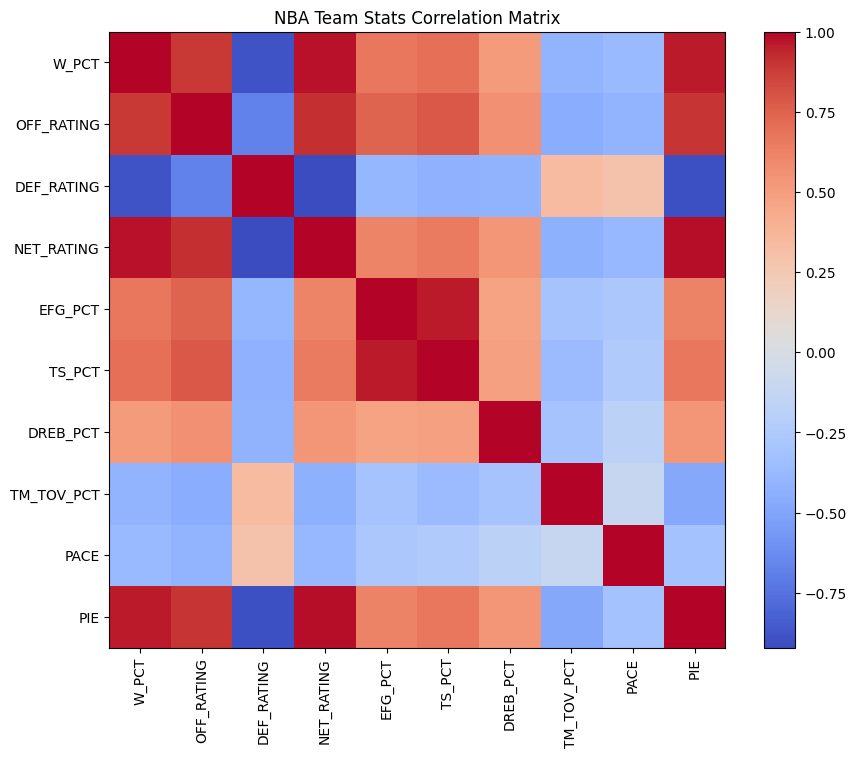

In [158]:
%pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('NBA Team Stats Correlation Matrix')

plt.show()

### Interpretation of Correlation Results

The correlation matrix reveals many important patterns in NBA team performance:

- The Net Rating (NET_RATING) shows the strongest correlation with winning percentage (0.98), implying that overall team efficiency is the best indicator of success.
- The Offensive Rating (OFF_RATING) has a strong positive correlation with winning (0.89), showing that scoring efficiency plays a key role in determining NBA game outcomes.
- The Defensive Rating (DEF_RATING) shows a strong negative correlation (-0.80), meaning that teams that allow fewer points per possession tend to win more games.

However, it is important to note that offensive metrics generally show slightly stronger statistical relationships with winning compared to defensive metrics. This suggests that while defense is highly important, offensive performance may have a marginally stronger influence during the regular season.

Additionally, metrics such as True Shooting Percentage and Effective Field Goal Percentage show strong relationships with both offensive rating and winning, reinforcing the importance of scoring efficiency.

### Defensive Performance vs Winning

To better understand the relationship between defense and success, a scatter plot was created comparing the Defensive Rating and Win Percentage. A linear regression line has been added to visualize the overall trend in the data.

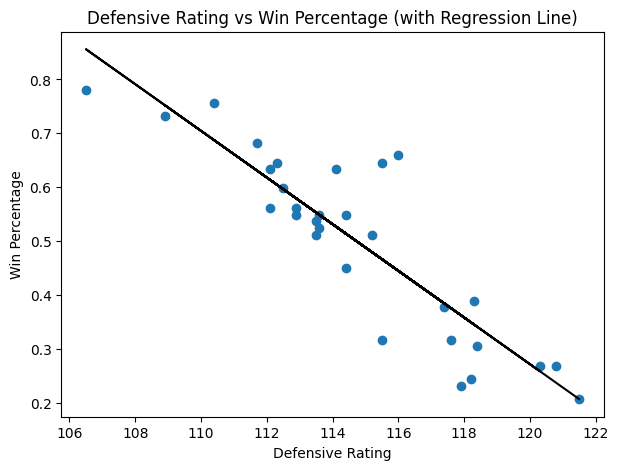

In [159]:
import numpy as np

plt.figure(figsize=(7,5))
plt.scatter(selected_df['DEF_RATING'], selected_df['W_PCT'])

x = selected_df['DEF_RATING']
y = selected_df['W_PCT']

m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color='black')

plt.xlabel('Defensive Rating')
plt.ylabel('Win Percentage')
plt.title('Defensive Rating vs Win Percentage (with Regression Line)')

plt.show()

### Interpretation of Defensive Relationship

The scatter plot shows a clear negative relationship between Defensive Rating and Win Percentage.

Since a lower Defensive Rating indicates better defensive performance, the trend suggests that teams with a stronger defensive capability tend to win more games.

However, the spread of points around the regression line indicates that defensive performance alone does not fully determine team success. While defense is an important factor, there is still noticeable variation in win percentage among teams with similar defensive ratings.

This suggests that other factors, more specifically offensive efficiency and overall team balance, also contribute significantly to winning outcomes beyond defensive performance alone.

In [160]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3. Regression Analysis
This section uses Ordinary Least Squares (OLS) regression models to measure how strongly offensive and defensive efficiency predict NBA team winning percentage during the 2025-26 season.

In [161]:
import statsmodels.api as sm

X = selected_df[['OFF_RATING', 'DEF_RATING']]

y = selected_df['W_PCT']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     218.7
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.09e-17
Time:                        15:03:20   Log-Likelihood:                 53.975
No. Observations:                  30   AIC:                            -102.0
Df Residuals:                      27   BIC:                            -97.75
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2850      0.663      0.430      0.6

In [162]:
X = selected_df[['DEF_RATING']]
y = selected_df['W_PCT']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     103.2
Date:                Wed, 27 May 2026   Prob (F-statistic):           6.77e-11
Time:                        15:03:20   Log-Likelihood:                 34.474
No. Observations:                  30   AIC:                            -64.95
Df Residuals:                      28   BIC:                            -62.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4625      0.489     11.179      0.0

In [163]:
X = selected_df[['OFF_RATING']]
y = selected_df['W_PCT']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     107.2
Date:                Wed, 27 May 2026   Prob (F-statistic):           4.46e-11
Time:                        15:03:20   Log-Likelihood:                 34.917
No. Observations:                  30   AIC:                            -65.83
Df Residuals:                      28   BIC:                            -63.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7389      0.506     -9.360      0.0

### Regression Analysis Insight

The regression results show that both offensive and defensive ratings significantly impact winning percentage. Offensive Rating has a slightly stronger predictive effect (coef = +0.028), while Defensive Rating also remains highly significant (coef = -0.025).

When combined, the model explains a large proportion of variation in team success (R² ≈ 0.96), suggesting that approximately 96% of differences in win percentage can be accounted for by these two efficiency metrics.

This shows that the NBA winning outcomes are significantly driven by a balance of offensive and defensive performance rather than one dominating factor, with the offensive performance having a marginally stronger influence in this dataset.

## 4. Overall Team Efficiency and Winning Success

Net Rating combines both offensive and defensive efficiency into a single metric, representing a team's overall point differential per 100 possessions.

This visualization examines how strongly connected overall team efficiency is to the winning percentage of an NBA team, allowing for a comparision between their combined impact versus their individual impact when analyzed seperately.

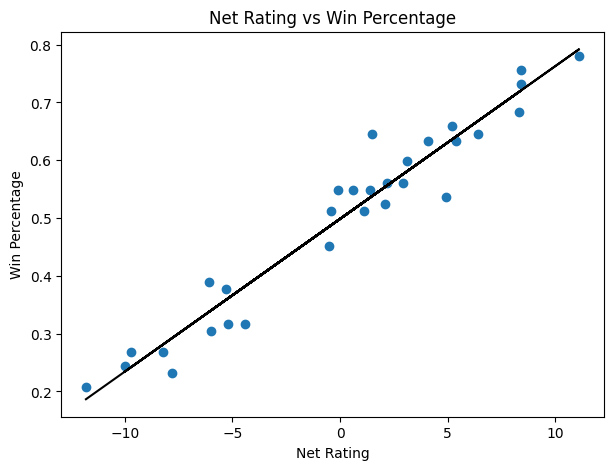

In [164]:
plt.figure(figsize=(7,5))

plt.scatter(selected_df['NET_RATING'], selected_df['W_PCT'])

x = selected_df['NET_RATING']
y = selected_df['W_PCT']

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black')
plt.xlabel('Net Rating')
plt.ylabel('Win Percentage')

plt.title('Net Rating vs Win Percentage')

plt.show()

### Correlation Comparison Table

In [165]:
comparison = correlation_matrix.loc[
    ['OFF_RATING', 'DEF_RATING', 'NET_RATING'],
    ['W_PCT']
]

comparison

,W_PCT
OFF_RATING,0.890417
DEF_RATING,-0.886921
NET_RATING,0.970743


### Comparative Efficiency Interpretation

The visualization shows an extremely strong positive relationship between Net Rating and Win Percentage.

The correlation matrix supports this relationship, showing that Net Rating had the strongest correlation with winning percentage in the dataset (r = 0.982), exceeding both Offensive Rating (r = 0.890) and Defensive Rating (r = -0.801).

Teams with higher Net Ratings consistently achieved better records during the 2025-26 NBA season, suggesting that overall offense-defense efficiency is one of the strongest indicators of team success.

This supports the idea that while offense and defense individually matter, the balance between the two may ultimately determine long-term winning outcomes more effectively than the individual efficiencies.

However, some deviation from the regression line still exists, this suggests that other factors such as injuries, roster depth, late-game execution, matchup dynamics and schedule difficulty could also influence team success.

## 5. Comparing Efficiency Rankings to Actual NBA Standings

Based on the previous analysis and findings, Net Rating demonstrated the strongest overall relationship with winning percentage among all evaluated variables.

This section applies Net Rating as a simplified indicator of overall efficiency and compares these rankings to the actual NBA standings in order to evaluate how accurately overall two-way efficiency reflects real team success.

To measure this relationship, Spearman's Rank Correlation was used to compare team rankings based on Net Rating against final league standings for 2025-26 NBA regular season.


In [166]:
analysis_df = selected_df[[
    'TEAM_NAME',
    'W_PCT',
    'NET_RATING'
]].copy()

analysis_df['Standings_Rank'] = (
    analysis_df['W_PCT']
    .rank(ascending=False, method='min')
    .astype(int)
)

analysis_df['NetRating_Rank'] = (
    analysis_df['NET_RATING']
    .rank(ascending=False, method='min').astype(int)
)

analysis_df = analysis_df.sort_values(
    by='Standings_Rank'
)

analysis_df

,TEAM_NAME,W_PCT,NET_RATING,Standings_Rank,NetRating_Rank
20,Oklahoma City Thunder,0.780,11.1,1,1
26,San Antonio Spurs,0.756,8.4,2,2
8,Detroit Pistons,0.732,8.4,3,2
1,Boston Celtics,0.683,8.3,4,4
7,Denver Nuggets,0.659,5.2,5,7
19,New York Knicks,0.646,6.4,6,5
13,Los Angeles Lakers,0.646,1.5,6,14
5,Cleveland Cavaliers,0.634,4.1,8,9
10,Houston Rockets,0.634,5.4,8,6
17,Minnesota Timberwolves,0.598,3.1,10,10


In [167]:
corr_matrix = analysis_df[[
    'Standings_Rank',
    'NetRating_Rank'
]].corr(method='spearman')

rho = corr_matrix.loc[
    'Standings_Rank',
    'NetRating_Rank'
]

print("--- Spearman Rank Correlation ---")
print("Spearman Correlation (Rho): "+ str(round(rho,4)))

--- Spearman Rank Correlation ---
Spearman Correlation (Rho): 0.9507


### Rank Correlation Insight 

Although the Spearman rank correlation showed a very strong relationship between Net Rating rankings and overall NBA standings, the analysis also presented several deviations between the statistical efficiency and final season outcomes.

For example, the Los Angeles Lakers finished significantly higher in the standings relative to their Net Rating rank. This outcome aligns with external analysis from NBA.com, which highlighted the Lakers’ exceptional clutch-time offensive efficiency, defensive improvement, and late-game execution throughout the season (Schuhmann, 2026). These factors likely played a role in the team to outperform their overall efficiency in close-game situations.

Similarly, the Charlotte Hornets produced a decent Net Rating rank of 8th overall despite finishing noticeably lower in the standings of 16th in the league. According to NBA.com analysis, Charlotte experienced extreme season splits, dominant blowout victories, and poor clutch-game performance, causing their efficiency metrics to outperform their actual standings position (Schuhmann, 2026). The article also noted that the Hornets posted one of the strongest five-man lineup Net Ratings in the league while struggling to consistently convert close games into wins, thereby revealing how other basketball factors can influence winning outcomes beyond overall efficiency metrics alone.

In contrast, teams such as the Oklahoma City Thunder and Boston Celtics showed strong alignment between standings rank and Net Rating rank, reinforcing the reliability of overall efficiency as a long-term indicator of team strength.

These findings suggest that while Net Rating is highly effective at evaluating overall team quality, other factors such as clutch performance, injuries, lineup consistency, schedule strength, and inconsistency in close-game outcomes may still influence final NBA standings beyond what efficiency metrics alone can explain.


<div style="padding-left: 36px; text-indent: -36px;">

## References

Schuhmann, J. (2026). *4 reasons why Lakers have evolved into a contender*. NBA.com. https://www.nba.com/news/4-reasons-los-angeles-lakers-are-contender

Schuhmann, J. (2026). *Hornets make some history amid their turnaround season*. NBA.com. https://www.nba.com/news/hornets-improvement-2025-26-season

NBA API. (2026). *LeagueDashTeamStats advanced statistics endpoint*. NBA Stats API.

</div>
